# 00 · Time-series data and reproducible setup

Start with what was observed: daily values, instantaneous measurements, annual peaks,
and paired field measurements represent different sampling processes.
This notebook loads the verified managed runtime and constructs Numerics time-series objects
used by headless BestFit models. It follows the explicit construction pattern in
Numerics-Python-Examples `10_time_series.ipynb` and BestFit Verification `TestData.cs`.

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from time import perf_counter
import numpy as np
import pandas as pd
from IPython.display import display
from bestfit_examples.runtime import load_bestfit
from bestfit_examples.raw import load_raw
from bestfit_examples.fresh import show
runtime = load_bestfit()
print(runtime)
from System import DateTime, Double
from Numerics.Data import TimeSeries, TimeInterval, SeriesOrdinate, BlockFunctionType
from bestfit_plots.adapters.input_data import time_series_plots

{'schemaVersion': 1, 'sourceCommit': 'db5807d6e3a85606797cda79542f2d51a80a57a6', 'numericsVersion': '2.2.0.0', 'bestFitVersion': '2.0.0.0', 'targetFramework': '.NETCoreApp,Version=v10.0', 'fileHashes': {'RMC.BestFit.dll': '8714d7e4e9d738e99e45c36d5581ce759e8fd535361b7a141d9647a9a5eac8dd', 'Numerics.dll': '364d2296a6024643a8bf0f60d1eaa8f5be5511563dea0b5d572074e45c27ea48'}}


## Frozen USGS observations

The original USGS example contains eight series. Daily discharge is a daily summary;
instantaneous discharge describes conditions at a timestamp; an annual peak is the largest event in a year.
Raw observations and metadata have been extracted without fitted objects or saved plot coordinates.
The inventory includes the large instantaneous records; the following construction cells use the same
daily and annual-peak records displayed in this example.

In [3]:
started = perf_counter()
raw = load_raw("usgs-download-example")
inventory = []
for name, item in raw["series"].items():
    records = item["records"]
    inventory.append({"Series": name, "Type": item["metadata"]["SeriesType"],
                      "Unit": item["metadata"]["UnitLabel"], "Records": len(records),
                      "Start": records[0]["Index"], "End": records[-1]["Index"],
                      "Missing": sum(not np.isfinite(float(r["Value"])) for r in records)})
display(pd.DataFrame(inventory))
print(raw["source"])

,Series,Type,Unit,Records,Start,End,Missing
0,USGS - 01134500 - Daily Discharge,DailyDischarge,Flow (cfs),29050,1947-01-01T00:00:00.0000000,2026-07-14T00:00:00.0000000,0
1,USGS - 01570500 - Measured Discharge,MeasuredDischarge,Flow (cfs),412,1897-03-31T05:00:00.0000000Z,2026-07-15T15:21:11.0000000Z,0
2,USGS - 01570500 - Measured Stage,MeasuredStage,Stage (ft),939,1897-03-31T05:00:00.0000000Z,2026-07-15T15:21:11.0000000Z,0
3,USGS - 01614000 - Peak Discharge,PeakDischarge,Flow (cfs),69,1929-04-17T00:00:00.0000000,2025-05-14T00:00:00.0000000,0
4,USGS - 01614000 - Peak Stage,PeakStage,Stage (ft),69,1929-04-17T00:00:00.0000000,2025-05-14T00:00:00.0000000,0
5,USGS - 01646500 - Instantaneous Discharge,InstantaneousDischarge,Flow (cfs),1272826,1972-06-09T01:00:00.0000000,2026-07-15T14:50:00.0000000,0
6,USGS - 01646500 - Instantaneous Stage,InstantaneousStage,Stage (ft),723856,2007-10-01T01:00:00.0000000,2026-07-15T14:50:00.0000000,0
7,USGS - 07010000 - Daily Stage,DailyStage,Value,15994,1982-10-01T00:00:00.0000000,2026-07-15T00:00:00.0000000,197


{'bytes': 15269888, 'relative_path': 'examples/1-time-series-data/1-usgs-download/usgs-download-example.bestfit', 'repository_commit': '3fa55a0f75bbd583e2fb7fce42180faa376f007c', 'sha256': 'bf48bf775c9ab88ad7135e5d0c45be5d08ad303eb0e95aa9e120ab17adf56921'}


## Construct daily discharge and calculate a transformation

Adding timestamped ordinates preserves actual dates and missing values. A missing measurement
remains NaN, never zero or silently interpolated. The 365-day moving average is calculated
by Numerics from the newly constructed series. Change `period` to examine another averaging interval.

Verified all 365-day means and calendar-month maxima against raw-observation arithmetic.


,Date,Monthly maximum
0,1947-01-21,180.0
1,1947-02-01,200.0
2,1947-03-27,295.0
3,1947-04-13,1770.0
4,1947-05-04,967.0
5,1947-06-04,1400.0
6,1947-07-24,523.0
7,1947-08-01,122.0
8,1947-09-23,52.0
9,1947-10-30,44.0


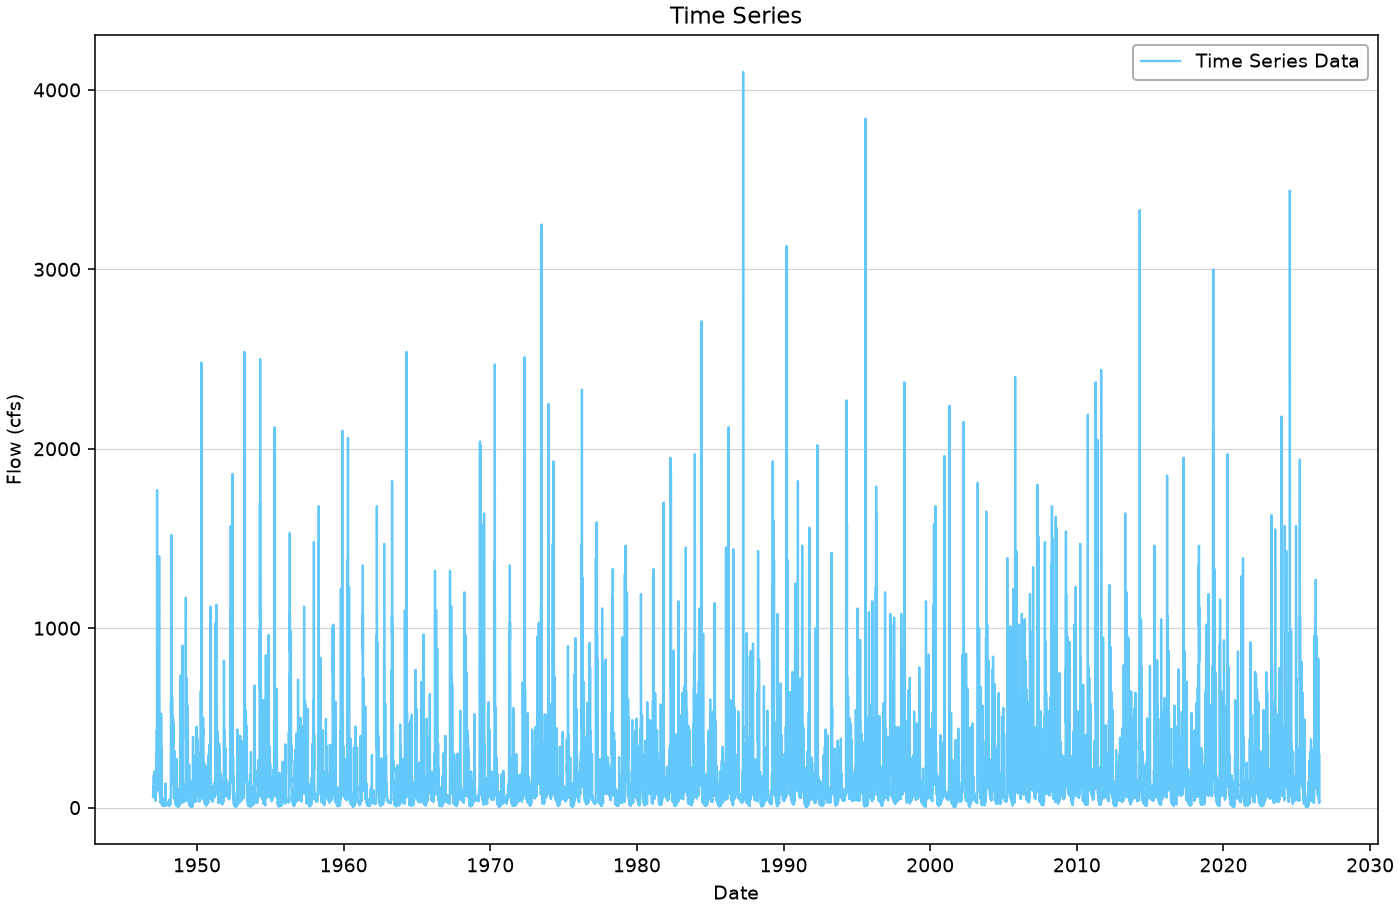

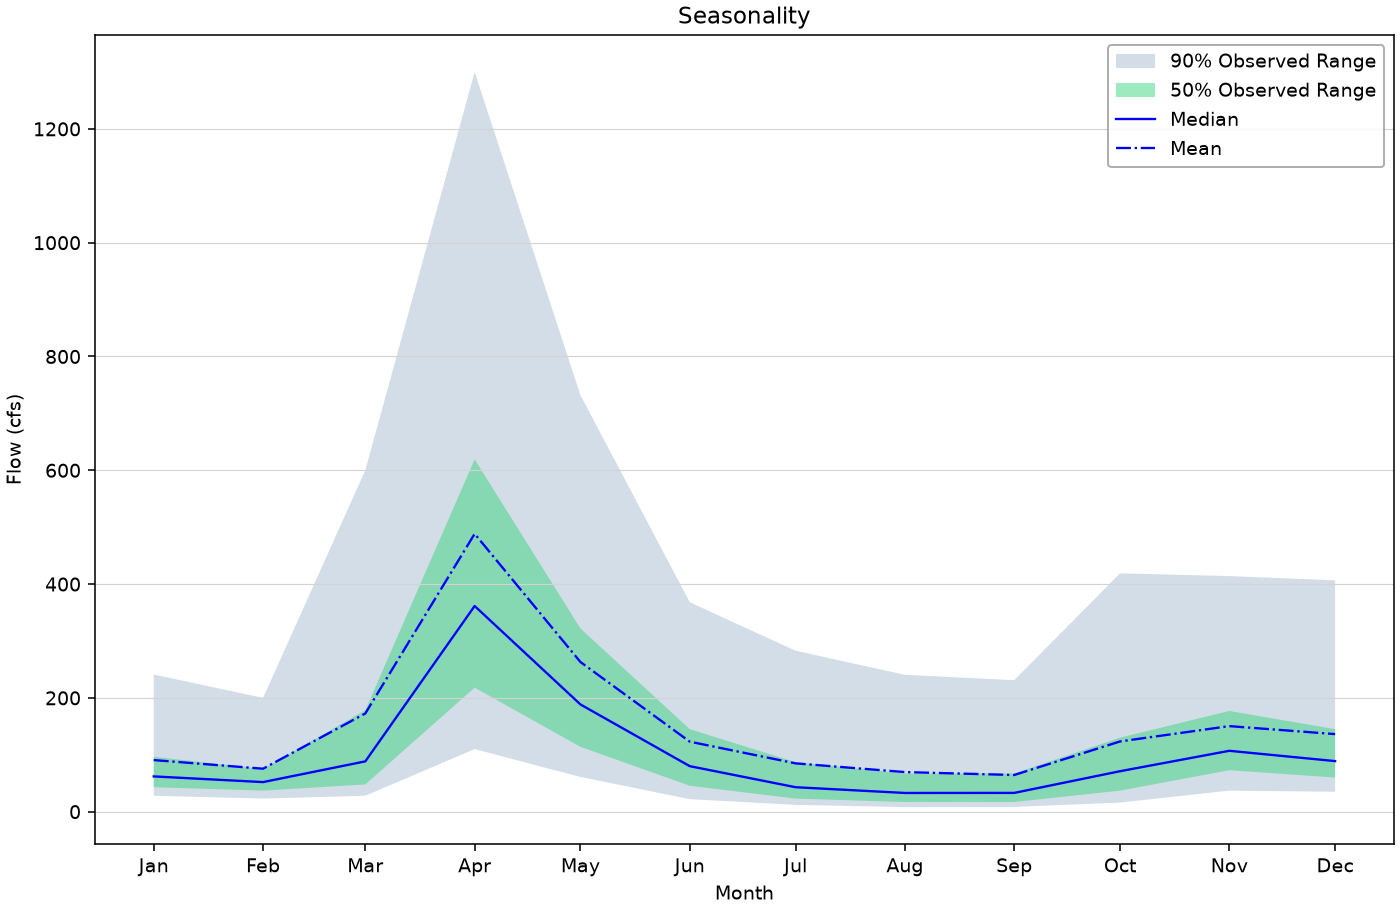

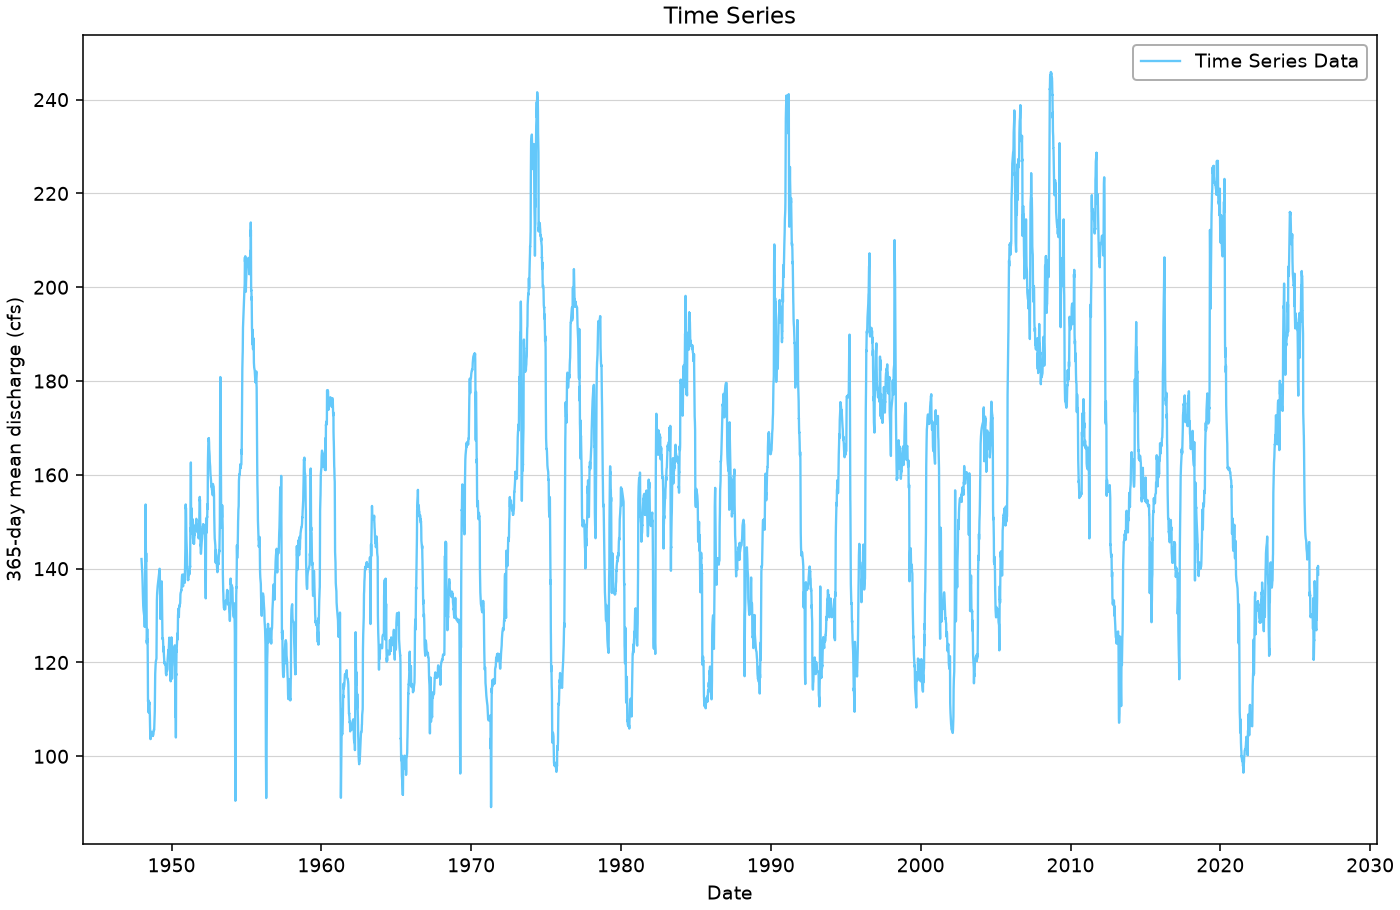

In [4]:
daily_name = "USGS - 01134500 - Daily Discharge"
daily_records = raw["series"][daily_name]["records"]
daily = TimeSeries(TimeInterval.OneDay)
for row in daily_records:
    daily.Add(SeriesOrdinate[DateTime, Double](DateTime.Parse(row["Index"]), float(row["Value"])))
moving_average = daily.MovingAverage(365)
monthly_maximum = daily.MonthlySeries(BlockFunctionType.Maximum)
assert daily.Count == len(daily_records)
# Check the transformations against independent arithmetic on the raw observations.
raw_values = np.array([float(row["Value"]) for row in daily_records])
expected_average = pd.Series(raw_values).rolling(365, min_periods=365).mean().iloc[364:]
np.testing.assert_allclose([float(p.Value) for p in moving_average], expected_average,
                           rtol=1e-12, atol=1e-9, equal_nan=True)
assert str(moving_average[0].Index.ToString("yyyy-MM-dd")) == daily_records[364]["Index"][:10]
raw_months = pd.DataFrame({"Date": pd.to_datetime([r["Index"] for r in daily_records]),
                          "Value": raw_values})
expected_maxima = raw_months.groupby(raw_months["Date"].dt.to_period("M"))["Value"].max()
np.testing.assert_allclose([float(p.Value) for p in monthly_maximum], expected_maxima,
                           rtol=0, atol=0, equal_nan=True)
print("Verified all 365-day means and calendar-month maxima against raw-observation arithmetic.")
display(pd.DataFrame([{"Date": str(p.Index.ToString("yyyy-MM-dd")), "Monthly maximum": float(p.Value)}
                      for p in monthly_maximum]).head(12))
source = {"kind": "rerun", "id": daily_name, "runId": "raw:" + raw["source"]["sha256"]}
daily_plots = time_series_plots(daily, source, raw["series"][daily_name]["metadata"]["UnitLabel"])
show(daily_plots["series"])
show(daily_plots["seasonality"])
show(time_series_plots(moving_average, source, "365-day mean discharge (cfs)")["series"])

## Annual peaks and monthly event frequency

Seasonality bands above describe the spread of monthly observations. They are not uncertainty
bounds for a fitted flood-frequency curve. Peak seasonality below is a monthly event-frequency histogram.
The source labels this sparse peak series `OneDay`; retain that metadata and its actual event dates.
ACF/PACF calculations in the canonical utilities keep the app's missing-data guard.

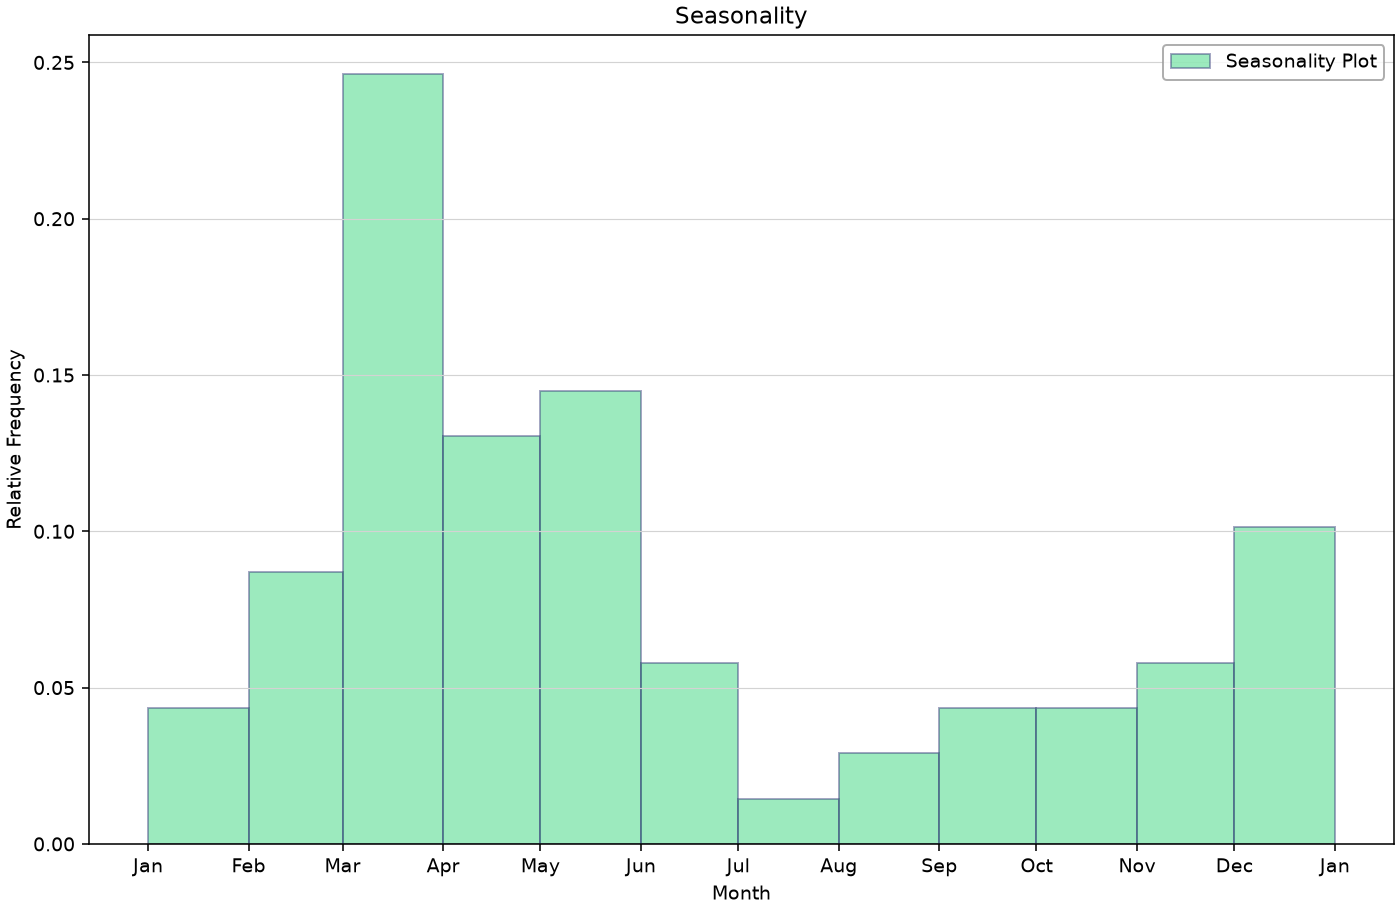

In [5]:
peak_name = "USGS - 01614000 - Peak Discharge"
peaks = TimeSeries(TimeInterval.OneDay)
for row in raw["series"][peak_name]["records"]:
    peaks.Add(SeriesOrdinate[DateTime, Double](DateTime.Parse(row["Index"]), float(row["Value"])))
peak_source = {"kind": "rerun", "id": peak_name, "runId": source["runId"]}
show(time_series_plots(peaks, peak_source, raw["series"][peak_name]["metadata"]["UnitLabel"], peak=True)["seasonality"])
assert peaks.Count == 69

## Field measurements and other import routes

Measured stage and discharge are separate field series. The source stores 939 stage records and
412 discharge records; calling every row a pair would be incorrect. Join timestamps explicitly
before using paired measurements for a rating curve, and inspect unmatched observations.
GHCN precipitation, CHMN, HEC-DSS and manual-entry inputs retain their original route and units.
The upstream ABOM example remains an optional online import, not a prerequisite.

In [6]:
stage_records = pd.DataFrame(raw["series"]["USGS - 01570500 - Measured Stage"]["records"])
flow_records = pd.DataFrame(raw["series"]["USGS - 01570500 - Measured Discharge"]["records"])
paired = stage_records.merge(flow_records, on="Index", how="inner", suffixes=("_stage", "_discharge"))
print(f"{len(stage_records)} stage records, {len(flow_records)} discharge records, {len(paired)} joined rows")
display(paired.head())
routes = ["ghcn-download-example", "chmn-download-example", "hec-dss-import-example", "manual-entry-example"]
route_inventory = []
for slug in routes:
    imported = load_raw(slug)
    for name, item in imported["series"].items():
        route_inventory.append({"Project": slug, "Series": name, "Route": item["metadata"]["EntryMethod"],
                                "Unit": item["metadata"]["UnitLabel"], "Records": len(item["records"])})
display(pd.DataFrame(route_inventory))
print(f"Data preparation and plots: {perf_counter() - started:.2f} s")

939 stage records, 412 discharge records, 410 joined rows


,Index,Value_stage,Value_discharge
0,1897-03-31T05:00:00.0000000Z,5.4199999999999999,58900
1,1897-05-15T05:00:00.0000000Z,7.8300000000000001,106000
2,1897-08-30T05:00:00.0000000Z,1.5,9570
3,1897-09-16T05:00:00.0000000Z,0.57999999999999996,3960
4,1897-11-17T05:00:00.0000000Z,2.5,17800


,Project,Series,Route,Unit,Records
0,ghcn-download-example,GHCN - USC00040741 - Daily Precipitation,GHCN,Precipitation (in),24106
1,ghcn-download-example,GHCN - USC00046685 - Daily Snow,GHCN,Snow (in),23772
2,chmn-download-example,CHMN - 08MG005 - Daily Discharge,CHMN,Flow (cms),40594
3,chmn-download-example,CHMN - 08MG005 - Daily Stage,CHMN,Stage (m),5097
4,chmn-download-example,CHMN - 08MG005 - Instantaneous Discharge,CHMN,Flow (cms),157213
5,chmn-download-example,CHMN - 08MG005 - Instantaneous Stage,CHMN,Stage (m),157213
6,chmn-download-example,CHMN - 08MG005 - Peak Discharge,CHMN,Flow (cms),64
7,chmn-download-example,CHMN - 08MG005 - Peak Stage,CHMN,Stage (m),13
8,hec-dss-import-example,Grapevine Dam - Inflow,HECDSS,CFS,2785
9,hec-dss-import-example,Grapevine Dam - Outflow,HECDSS,CFS,2785


Data preparation and plots: 10.12 s


**Adapt this example:** provide timestamp/value rows from your own CSV or measurement source,
select the appropriate `TimeInterval`, construct `TimeSeries`, and call its calculation methods.
Keep units, observation timing and missing values explicit. Notebook 01 prepares these observations
for frequency analysis; subsequent notebooks construct models and execute estimation.